# Time Series Forecasting of Tesla Stock Prices Using Machine Learning

### Importing relevant Libraries and Loading  Dataset
We import pandas for data manipulation and load the Tesla stock CSV file.


In [2]:
# Import pandas library for data manipulation
import pandas as pd

# Loading the tesla.csv file
df = pd.read_csv("tesla.csv", skiprows=2)

# Reseting the DataFrame index to start from 0
df.reset_index(drop=True, inplace=True)

In [3]:
# Assign new column names to the DataFrame
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

### Converting Data Types

In [4]:
# Converting Date column from text string to datetime object
df["Date"] = pd.to_datetime(df["Date"])

# Defining the columns that should be numeric
numeric_cols = ["Close", "High", "Low", "Open", "Volume"]

# Converting all numeric columns from text to float for mathematical operations
df[numeric_cols] = df[numeric_cols].astype(float)

### Seting Time Index and Frequency.

In [5]:
# Seting the Date as the DataFrame index 
df.set_index("Date", inplace=True)

# Seting business day frequency so every weekday has a row (even holidays)
df = df.asfreq('B')

# Forward fill missing values by carrying last known price into holiday gaps
df.ffill(inplace=True)

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500.0
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500.0
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000.0
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500.0
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500.0
...,...,...,...,...,...
2026-04-03,360.589996,370.279999,359.029999,364.200012,83031200.0
2026-04-06,352.820007,367.720001,346.640015,362.589996,77697600.0
2026-04-07,346.649994,348.019989,337.239990,346.440002,74515400.0


### Inspecting cleaned dataset

In [6]:
# Display the first 5 rows to preview the data
print(df.head())

# Display DataFrame info
print(df.info())

                Close       High        Low       Open       Volume
Date                                                               
2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500.0
2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500.0
2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000.0
2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500.0
2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500.0
<class 'pandas.DataFrame'>
DatetimeIndex: 1636 entries, 2020-01-02 to 2026-04-09
Freq: B
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1636 non-null   float64
 1   High    1636 non-null   float64
 2   Low     1636 non-null   float64
 3   Open    1636 non-null   float64
 4   Volume  1636 non-null   float64
dtypes: float64(5)
memory usage: 76.7 KB
None


### Visualizing the Closing Price

Plot Tesla's closing price over time to observe trend, volatility and events.


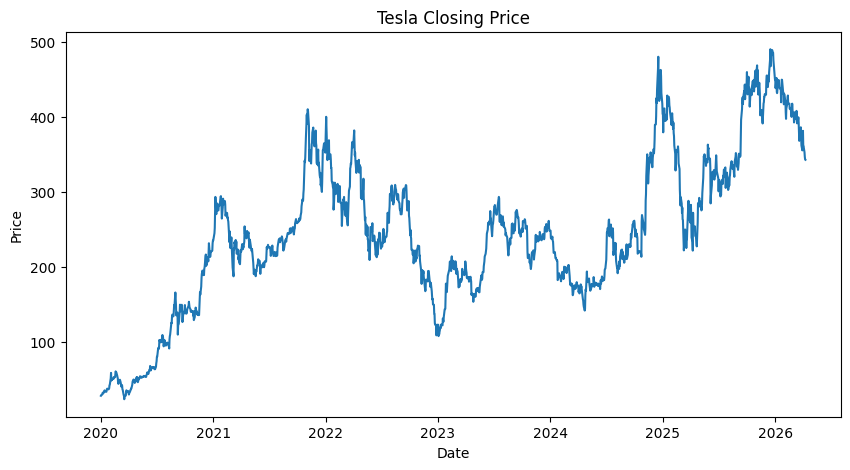

In [7]:
# Importing matplotlib 
import matplotlib.pyplot as plt

# Creating a figure with specified size (10 inches wide, 5 inches tall)
plt.figure(figsize=(10,5))

# Ploting the closing price over time
plt.plot(df['Close'])

# Adding title and axis labels
plt.title("Tesla Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")

# Displaying the plot
plt.show()

### Spliting the dataset into training and testing

Dataset was splited into 80% for training and 20% for testing.

In [8]:
# Importing the evaluation metrics and numpy
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Training set: first 80% of data
split_idx = int(len(df) * 0.8)

# Test set: last 20% of data
test_days = len(df) - split_idx

# Close price for model training
train_data = df['Close'][:split_idx].copy()
test_data = df['Close'][-test_days:].copy()

print(f"Total data points: {len(df)}")
print(f"Training set size: {len(train_data)} (first 80%)")
print(f"Test set size: {len(test_data)} (last 20%)")
print(f"\nTraining period: {train_data.index[0].date()} to {train_data.index[-1].date()}")
print(f"Test period: {test_data.index[0].date()} to {test_data.index[-1].date()}")

Total data points: 1636
Training set size: 1308 (first 80%)
Test set size: 328 (last 20%)

Training period: 2020-01-02 to 2025-01-06
Test period: 2025-01-07 to 2026-04-09


## Machine Learning Model (Random Forest approach )

In [9]:
# Importing Random Forest Regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# Feature engineering function: converts time series into supervised learning format
def create_features(df, target_col='Close', lags=[1,2,3], windows=[7,14,30]):
    df_features = df.copy()
    
    # Createint lag features: value at 1, 2, and 3 days ago
    for lag in lags:
        df_features[f'{target_col}_lag_{lag}'] = df_features[target_col].shift(lag)
    
    # Create rolling statistics: moving mean and standard deviation
    for window in windows:
        df_features[f'{target_col}_roll_mean_{window}'] = df_features[target_col].rolling(window=window).mean()
        df_features[f'{target_col}_roll_std_{window}'] = df_features[target_col].rolling(window=window).std()
    
    # Create time-based features from the date index
    df_features['day_of_week'] = df_features.index.dayofweek  # Monday=0, Friday=4
    df_features['month'] = df_features.index.month            # January=1, December=12
    df_features['quarter'] = df_features.index.quarter        # Q1=1, Q4=4
    
    # Drop rows with NaN values (created by lag and rolling operations)
    return df_features.dropna()

# Generate features from the full DataFrame
features_df = create_features(df, 'Close')

# Separate input features (X) and target variable (y)
X_all = features_df.drop('Close', axis=1)
y_all = features_df['Close']

# Use same split logic: first 80% for training, last 20% for testing
split_idx_rf = int(len(X_all) * 0.8)

# Training data: first 80%
X_train_rf = X_all[:split_idx_rf]
y_train_rf = y_all[:split_idx_rf]

# Find the last 20% in the feature-engineered data
test_start_date = df.index[-test_days]
test_mask = features_df.index >= test_start_date
X_test_rf = X_all[test_mask]
y_test_rf = y_all[test_mask]

# Rolling 1-step-ahead forecast for Random Forest
rolling_preds_rf = []

# Start with initial training data
X_train_expanding = X_train_rf.copy()
y_train_expanding = y_train_rf.copy()

# Get all data up to and including test period for expanding window
full_features = features_df.copy()
full_X = full_features.drop('Close', axis=1)
full_y = full_features['Close']

# Indices for the test period in the features_df
test_indices = features_df.index[test_mask]

for i, test_date in enumerate(test_indices):
    # Train Random Forest on expanding window
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train_expanding, y_train_expanding)
    
    # Predict the next day
    x_pred = full_X.loc[[test_date]]
    pred = rf_model.predict(x_pred)[0]
    rolling_preds_rf.append(pred)
    
    # Append actual observation to expanding training window
    X_train_expanding = pd.concat([X_train_expanding, full_X.loc[[test_date]]])
    y_train_expanding = pd.concat([y_train_expanding, full_y.loc[[test_date]]])

# Calculate MAE and RMSE
mae_rf = mean_absolute_error(y_test_rf, rolling_preds_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, rolling_preds_rf))
print(f"Random Forest Rolling MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")

Random Forest Rolling MAE: 4.59, RMSE: 6.19


## Random Forest Rolling Predictions vs Actual

Visualize the Random Forest rolling model's predictions against the actual closing prices on the last 20% of data.

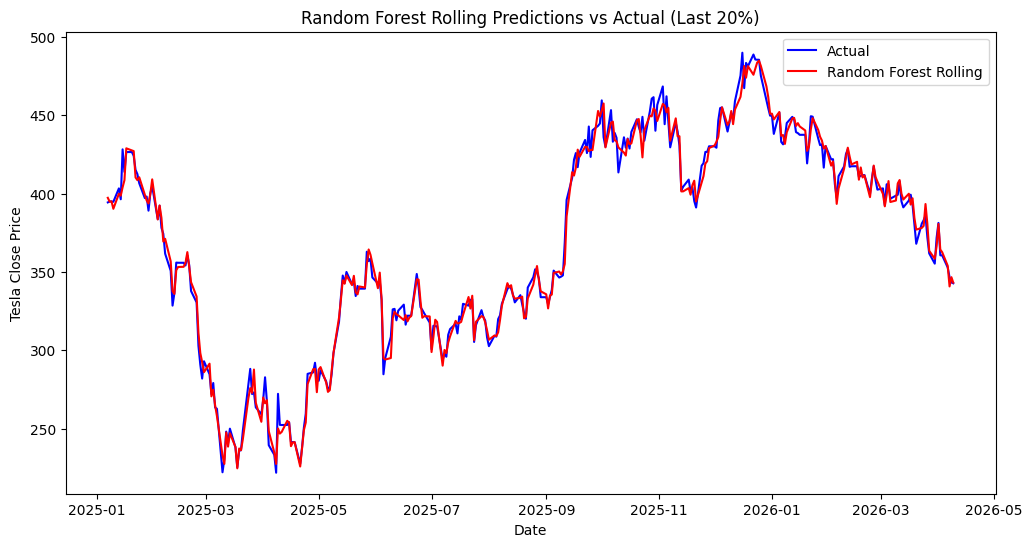

In [10]:
# Create a figure for the Random Forest prediction plot
plt.figure(figsize=(12,6))

# Plot actual test prices (blue)
plt.plot(y_test_rf.index, y_test_rf, label='Actual', color='blue')

# Plot Random Forest rolling predictions (red)
plt.plot(y_test_rf.index, rolling_preds_rf, label='Random Forest Rolling', color='red')

# Add title, labels, and legend
plt.title('Random Forest Rolling Predictions vs Actual (Last 20%)')
plt.xlabel('Date')
plt.ylabel('Tesla Close Price')
plt.legend()


# Display the plot
plt.show()

## Forecasting Next 30 Days

In [11]:
# For Random Forest, we need to create features iteratively
from sklearn.ensemble import RandomForestRegressor

# Create features for the full dataset
def create_features(data, lags=30):
    df_feat = data.copy()
    for lag in range(1, lags + 1):
        df_feat[f'lag_{lag}'] = df_feat['Close'].shift(lag)
    df_feat['rolling_mean_5'] = df_feat['Close'].rolling(window=5).mean()
    df_feat['rolling_std_5'] = df_feat['Close'].rolling(window=5).std()
    df_feat['rolling_mean_20'] = df_feat['Close'].rolling(window=20).mean()
    df_feat['rolling_std_20'] = df_feat['Close'].rolling(window=20).std()
    return df_feat

# Create feature dataset
df_rf = df[['Close']].copy()
df_rf_features = create_features(df_rf)
df_rf_features = df_rf_features.dropna()

feature_cols = [col for col in df_rf_features.columns if col != 'Close']

# Train on all available data
X_rf_full = df_rf_features[feature_cols]
y_rf_full = df_rf_features['Close']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_rf_full, y_rf_full)

# Iterate to forecast 30 days
rf_forecast = []
last_30_values = df['Close'].iloc[-30:].tolist()

for i in range(30):
    # Create features for prediction
    features = {}
    for lag in range(1, 31):
        if lag <= len(last_30_values):
            features[f'lag_{lag}'] = last_30_values[-lag]
        else:
            features[f'lag_{lag}'] = last_30_values[0]
    
    # Rolling mean and std
    features['rolling_mean_5'] = np.mean(last_30_values[-5:])
    features['rolling_std_5'] = np.std(last_30_values[-5:])
    features['rolling_mean_20'] = np.mean(last_30_values[-20:])
    features['rolling_std_20'] = np.std(last_30_values[-20:])
    
    X_pred = pd.DataFrame([features])
    pred = rf_model.predict(X_pred)[0]
    rf_forecast.append(pred)
    last_30_values.append(pred)
    last_30_values.pop(0)

# Create forecast dates and dataframe
from pandas.tseries.offsets import BusinessDay
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + BusinessDay(1), periods=30, freq='B')
forecast_df = pd.DataFrame(index=forecast_dates)
forecast_df['RF_Forecast'] = rf_forecast

print("Random Forest 30-Day Forecast:")
print(forecast_df)

Random Forest 30-Day Forecast:
            RF_Forecast
2026-04-10   341.185497
2026-04-13   336.162865
2026-04-14   332.065166
2026-04-15   317.424565
2026-04-16   309.150832
2026-04-17   308.247932
2026-04-20   304.703264
2026-04-21   305.598666
2026-04-22   305.179865
2026-04-23   303.667632
2026-04-24   302.563598
2026-04-27   301.818497
2026-04-28   302.820197
2026-04-29   304.699765
2026-04-30   303.152965
2026-05-01   302.429098
2026-05-04   301.980831
2026-05-05   301.649431
2026-05-06   303.431765
2026-05-07   304.903666
2026-05-08   301.520765
2026-05-11   298.406365
2026-05-12   298.095433
2026-05-13   298.467168
2026-05-14   298.878002
2026-05-15   299.510835
2026-05-18   298.000368
2026-05-19   298.105369
2026-05-20   298.400369
2026-05-21   299.135136


### Visualizing the 30-Day Forecast

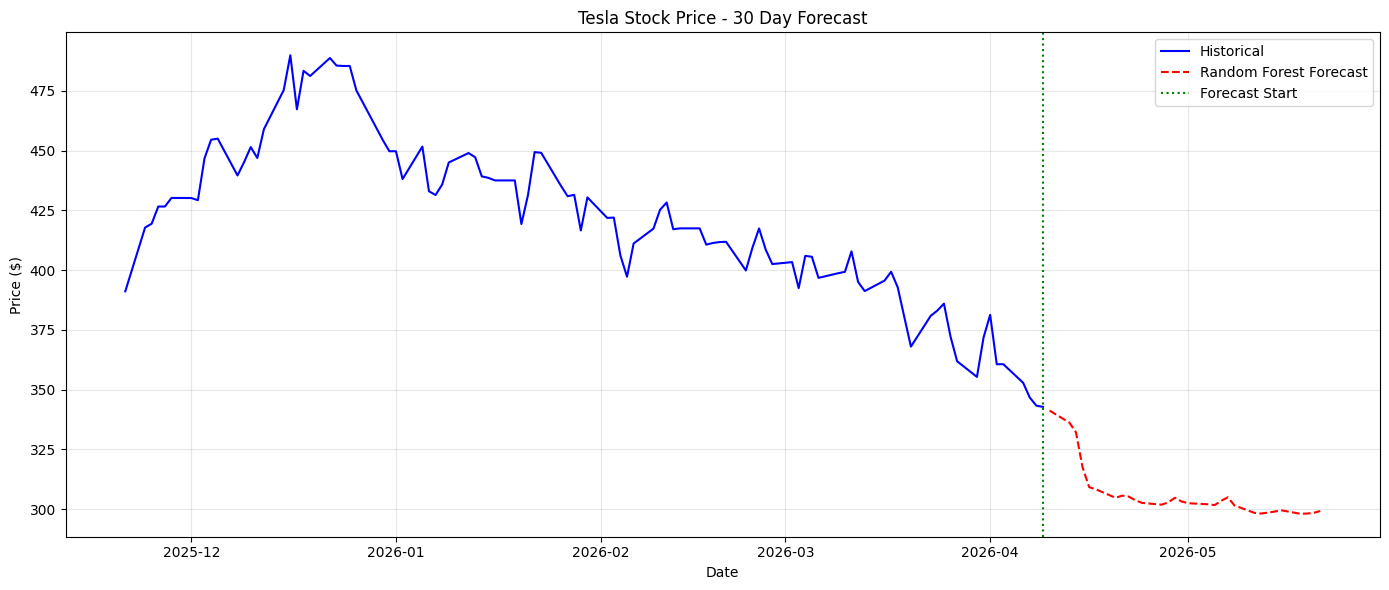


Forecast period: 2026-04-10 to 2026-05-21
RF forecast range: $298.00 - $341.19


In [12]:
# Plot historical data and 30-day forecast
plt.figure(figsize=(14,6))

# Plot last 100 days of actual data
plt.plot(df.index[-100:], df['Close'].iloc[-100:], label='Historical', color='blue')

# Plot Random Forest forecast
plt.plot(forecast_df.index, forecast_df['RF_Forecast'], label='Random Forest Forecast', color='red', linestyle='--')

plt.axvline(x=df.index[-1], color='green', linestyle=':', label='Forecast Start')
plt.title('Tesla Stock Price - 30 Day Forecast')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nForecast period: {forecast_dates[0].date()} to {forecast_dates[-1].date()}")
print(f"RF forecast range: ${min(rf_forecast):.2f} - ${max(rf_forecast):.2f}")